# TODO 

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Config + Load Analysis Class</h1>

In [1]:
import pandas as pd
pd.set_option('display.max_rows', 1000000)
pd.set_option('display.max_columns', 1000000)
pd.set_option('display.max_colwidth', 10000000)

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import polars as pl 
_=pl.Config.set_tbl_cols(1000000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)


%load_ext autoreload 
%autoreload 2

import importlib

SecondOrderShapNetworkAnalyzer = getattr(
    importlib.import_module("2_second_order_shap_analysis"), 
    "SecondOrderShapNetworkAnalyzer"
)

analyzer = SecondOrderShapNetworkAnalyzer()

import yaml 

with open('./1_variable_config.yaml', 'r') as file:
    CONFIG = yaml.safe_load(file)


2026-02-09 22:00:57.390 | SUCCESS  | 2_second_order_shap_analysis:__post_init__:36 - Class initialized and loaded.


<h1 style="color: teal; font-weight: bold; font-size: 48px;">Retrieve SHAP Metrics</h1>

In [ ]:
example = analyzer.retrieve_shap_values_for_metric(metric = "Signed-Local-SHAP-Mean-Bound-Only")
example.sample(20)

In [ ]:
for cell_line in CONFIG["CELL_LINES"]: 
    total_rows = example.filter(
        (pl.col("Cell Line") == cell_line) & 
        (pl.col("Column Type") == "interaction")
    ).height
    
    tmp = example.filter(
        (pl.col("Cell Line") == cell_line) & 
        (pl.col("Value - Signed-Local-SHAP-Mean-Bound-Only").abs() >= .0001) & 
        (pl.col("Column Type") == "interaction")
    )

    total_rows
    tmp.head()
    

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Interaction Heatmaps</h1>

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        HepG2_options = {
            "highlight": highlight,
            
            "figsize": (22, 10),
            'dpi': 600,
            'tick_fontsize': 2, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.05, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "HepG2", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **HepG2_options
        )

In [ ]:
for source in CONFIG["PPI_SOURCES"]: 
    for highlight in CONFIG["PPI_TYPES"]: 
    
        K562_options = {
            "highlight": highlight,
            
            "figsize": (24, 11),
            'dpi': 600,
            'tick_fontsize': 1.5, 
            'title_fontsize': 20, 
            'cell_linewidth': 0.02, 
            'legend_titlesize': 15, 
            'label_padding': 5
        }
        
        analyzer.plot_side_by_side_heatmaps_for_min_1_ppi(
            cell_line = "K562", 
            ppi_source= source, 
            metric = 'Signed-Local-SHAP-Mean-Bound-Only',
            **K562_options
        )

<h1 style="color: teal; font-weight: bold; font-size: 48px;">PPI ROC/PRC Curves</h1>

In [ ]:
analyzer.plot_roc_and_prc_curves_for_metric(metric = 'Signed-Local-SHAP-Mean-Bound-Only')

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Actual PSI by Binding for All Position PPI-Only Interactions</h1>

In [ ]:
analyzer.plot_actual_psi_by_binding_for_PPI()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Distributions of PPI/Non-PPI Values</h1>

In [ ]:
analyzer.ppi_vs_non_ppi_shap_value_distributions(metric = "Signed-Local-SHAP-Mean-Bound-Only")

In [ ]:
analyzer.ppi_type_shap_value_distributions(metric = "Signed-Local-SHAP-Mean-Bound-Only")

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Interaction Importance Networks</h1>

In [ ]:
importance_network_info = analyzer.retrieve_importance_network()

In [ ]:
analyzer.plot_edge_weights_per_position()

In [ ]:
analyzer.plot_average_importance_between_positions()

<h1 style="color: teal; font-weight: bold; font-size: 48px;">Top Interactions & Cell Line Interaction Similarity</h1>

In [ ]:
analyzer.top_interactions_per_cell_line()

In [ ]:
analyzer.plot_interaction_cell_line_similarity_scatterplot(label_top_points = 30)

In [ ]:
analyzer.create_top_cell_line_average_interactions_barplot()

In [ ]:
analyzer.plot_interaction_sign_concordance_over_shap_thresholds()

In [ ]:
analyzer.plot_position_combination_directionality()

In [ ]:
analyzer.retrieve_cell_line_concordant_interaction_values_for_rbp_prefix(
    rbp_prefix="RBM", 
    position1=3, 
    position2=4
)

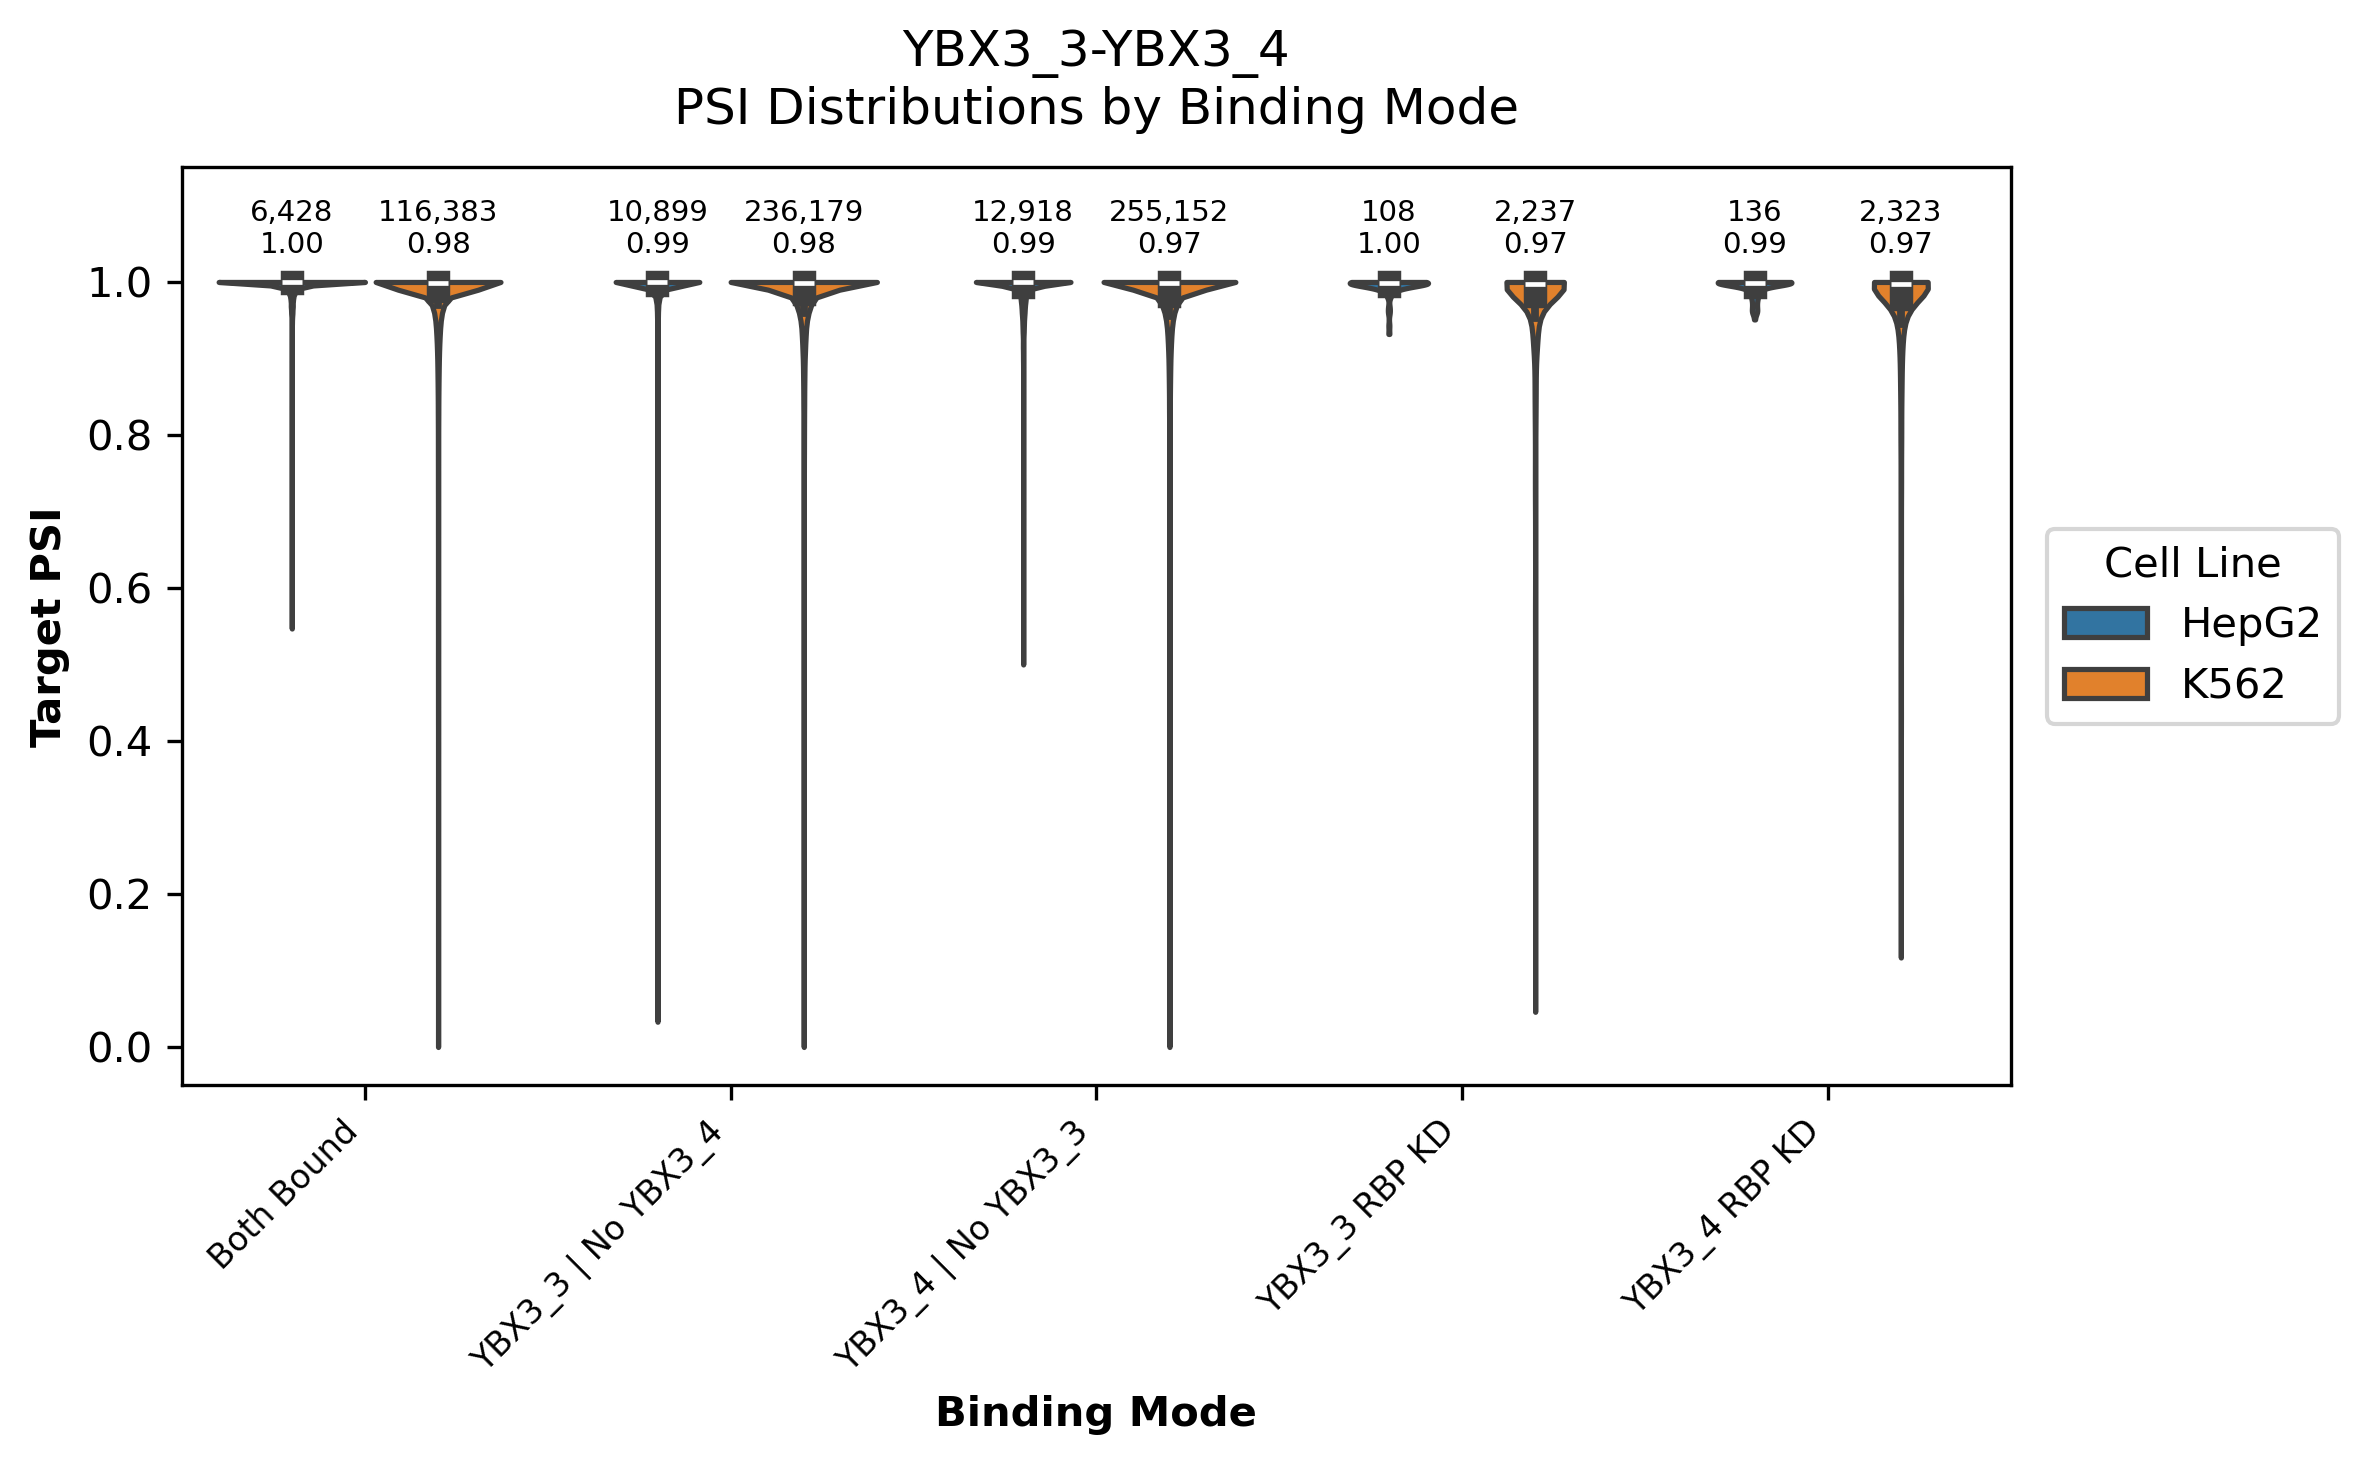

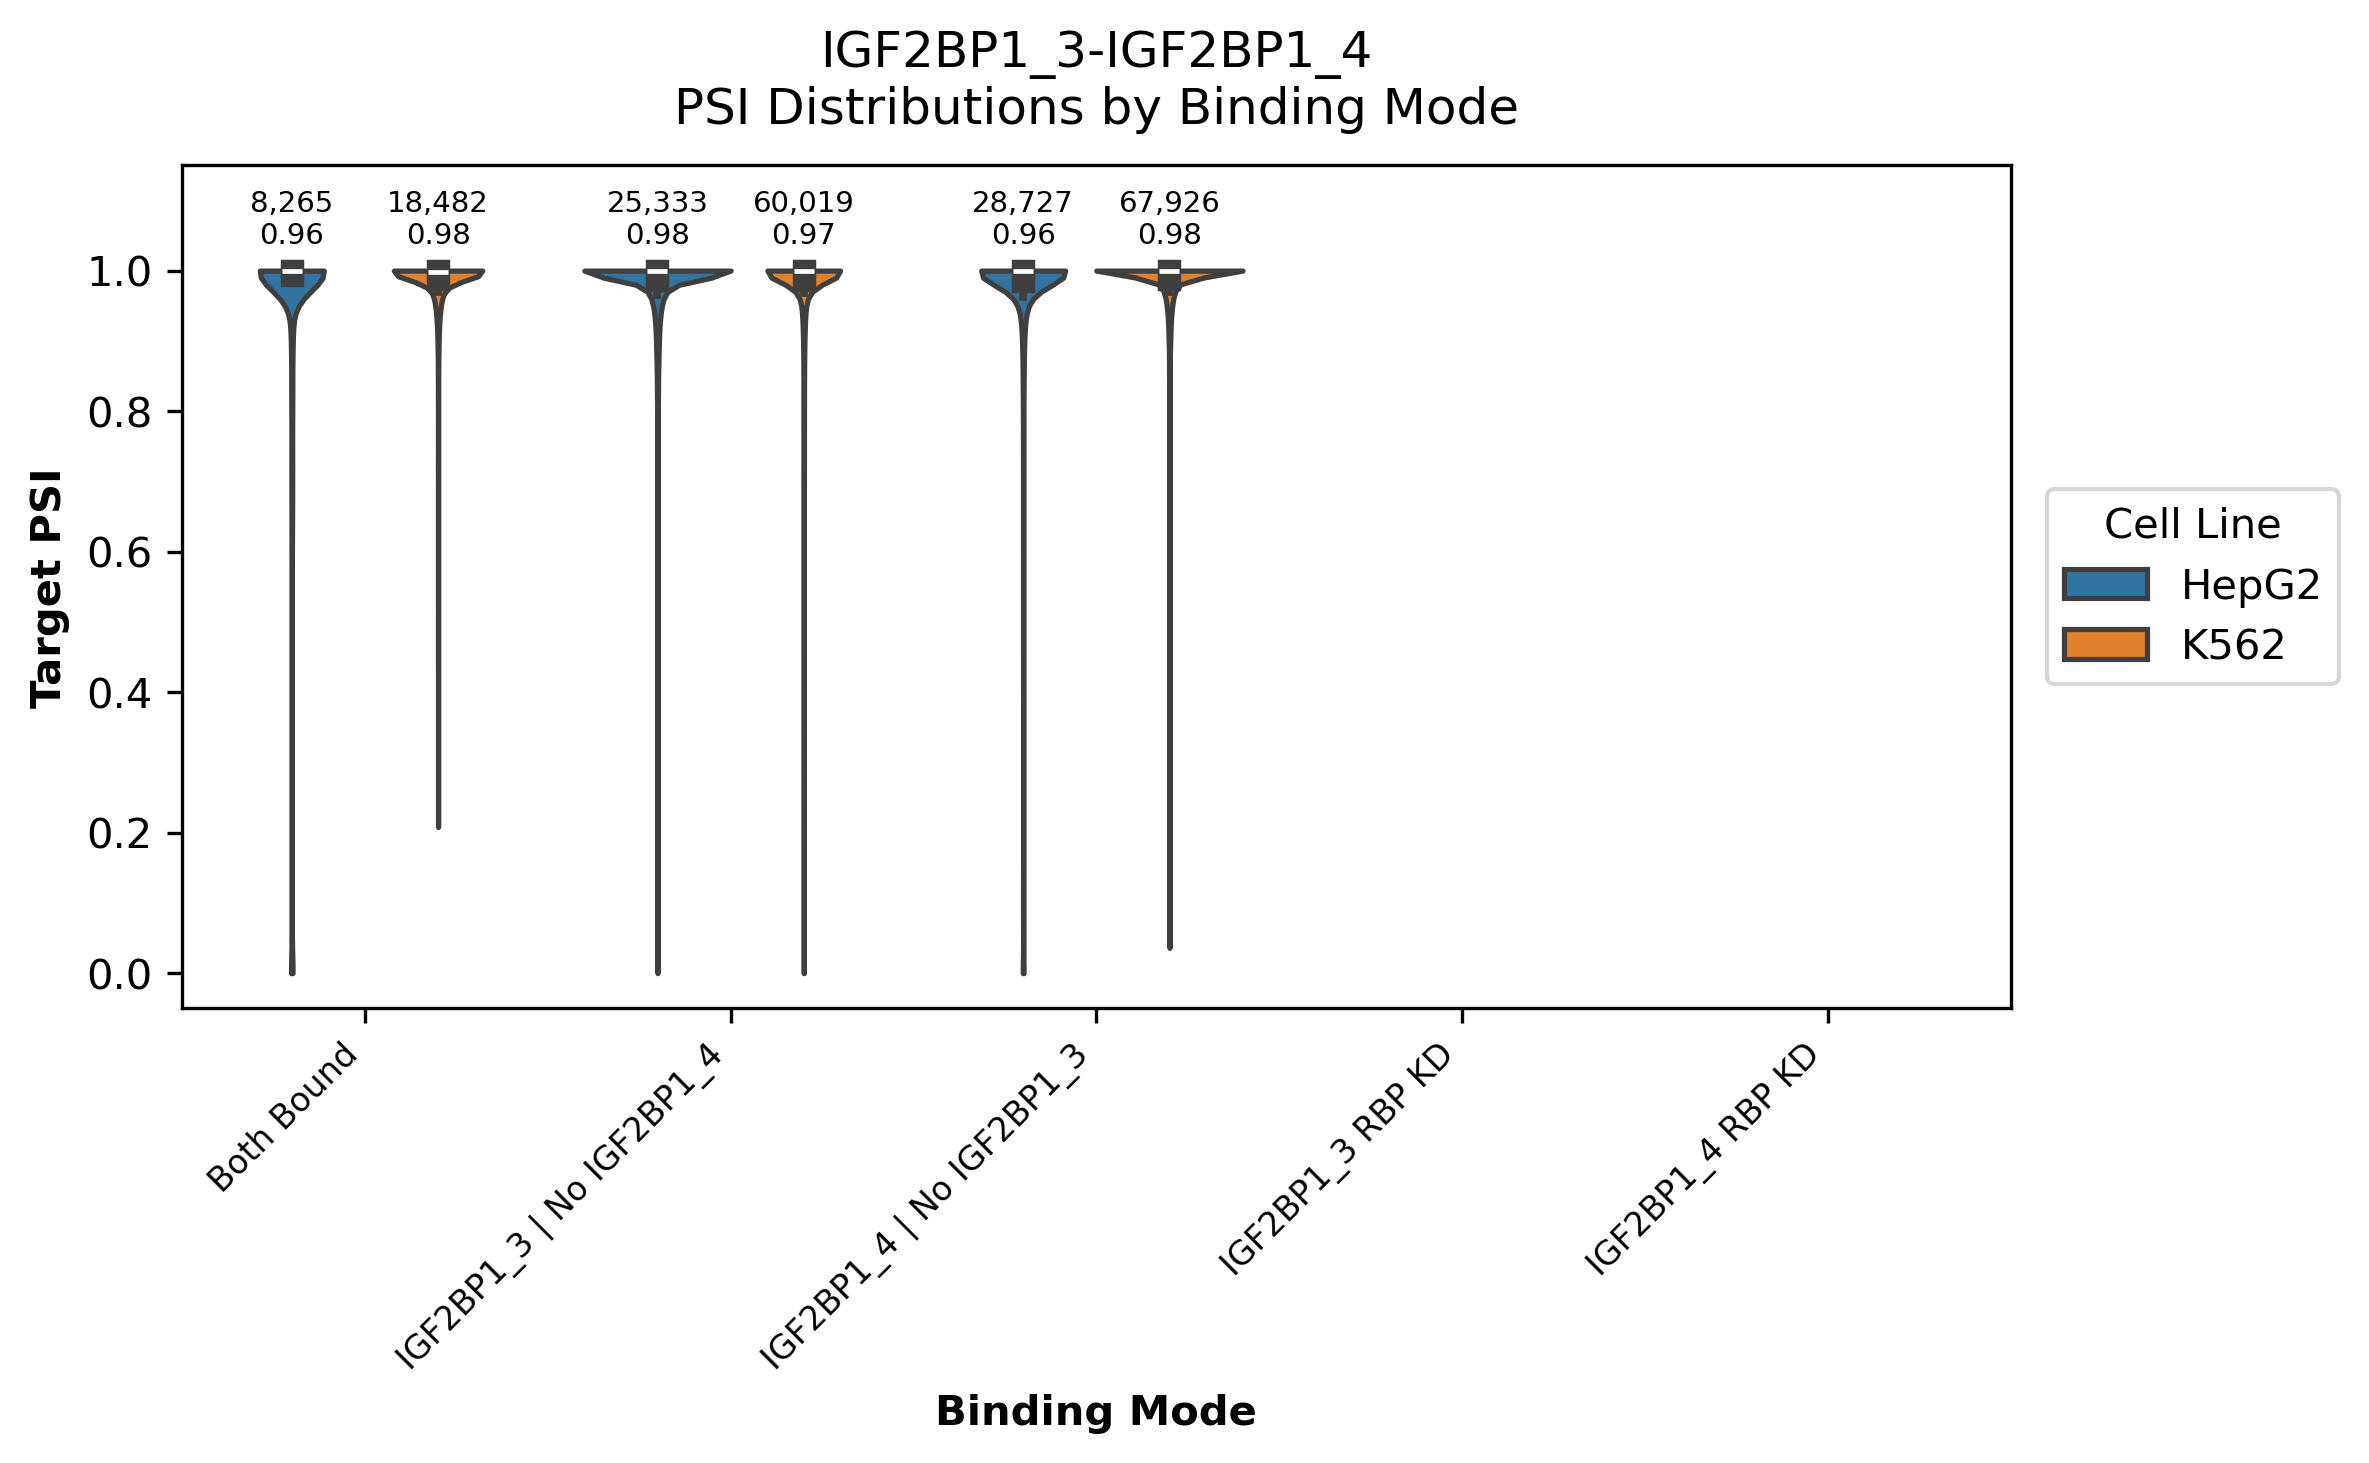

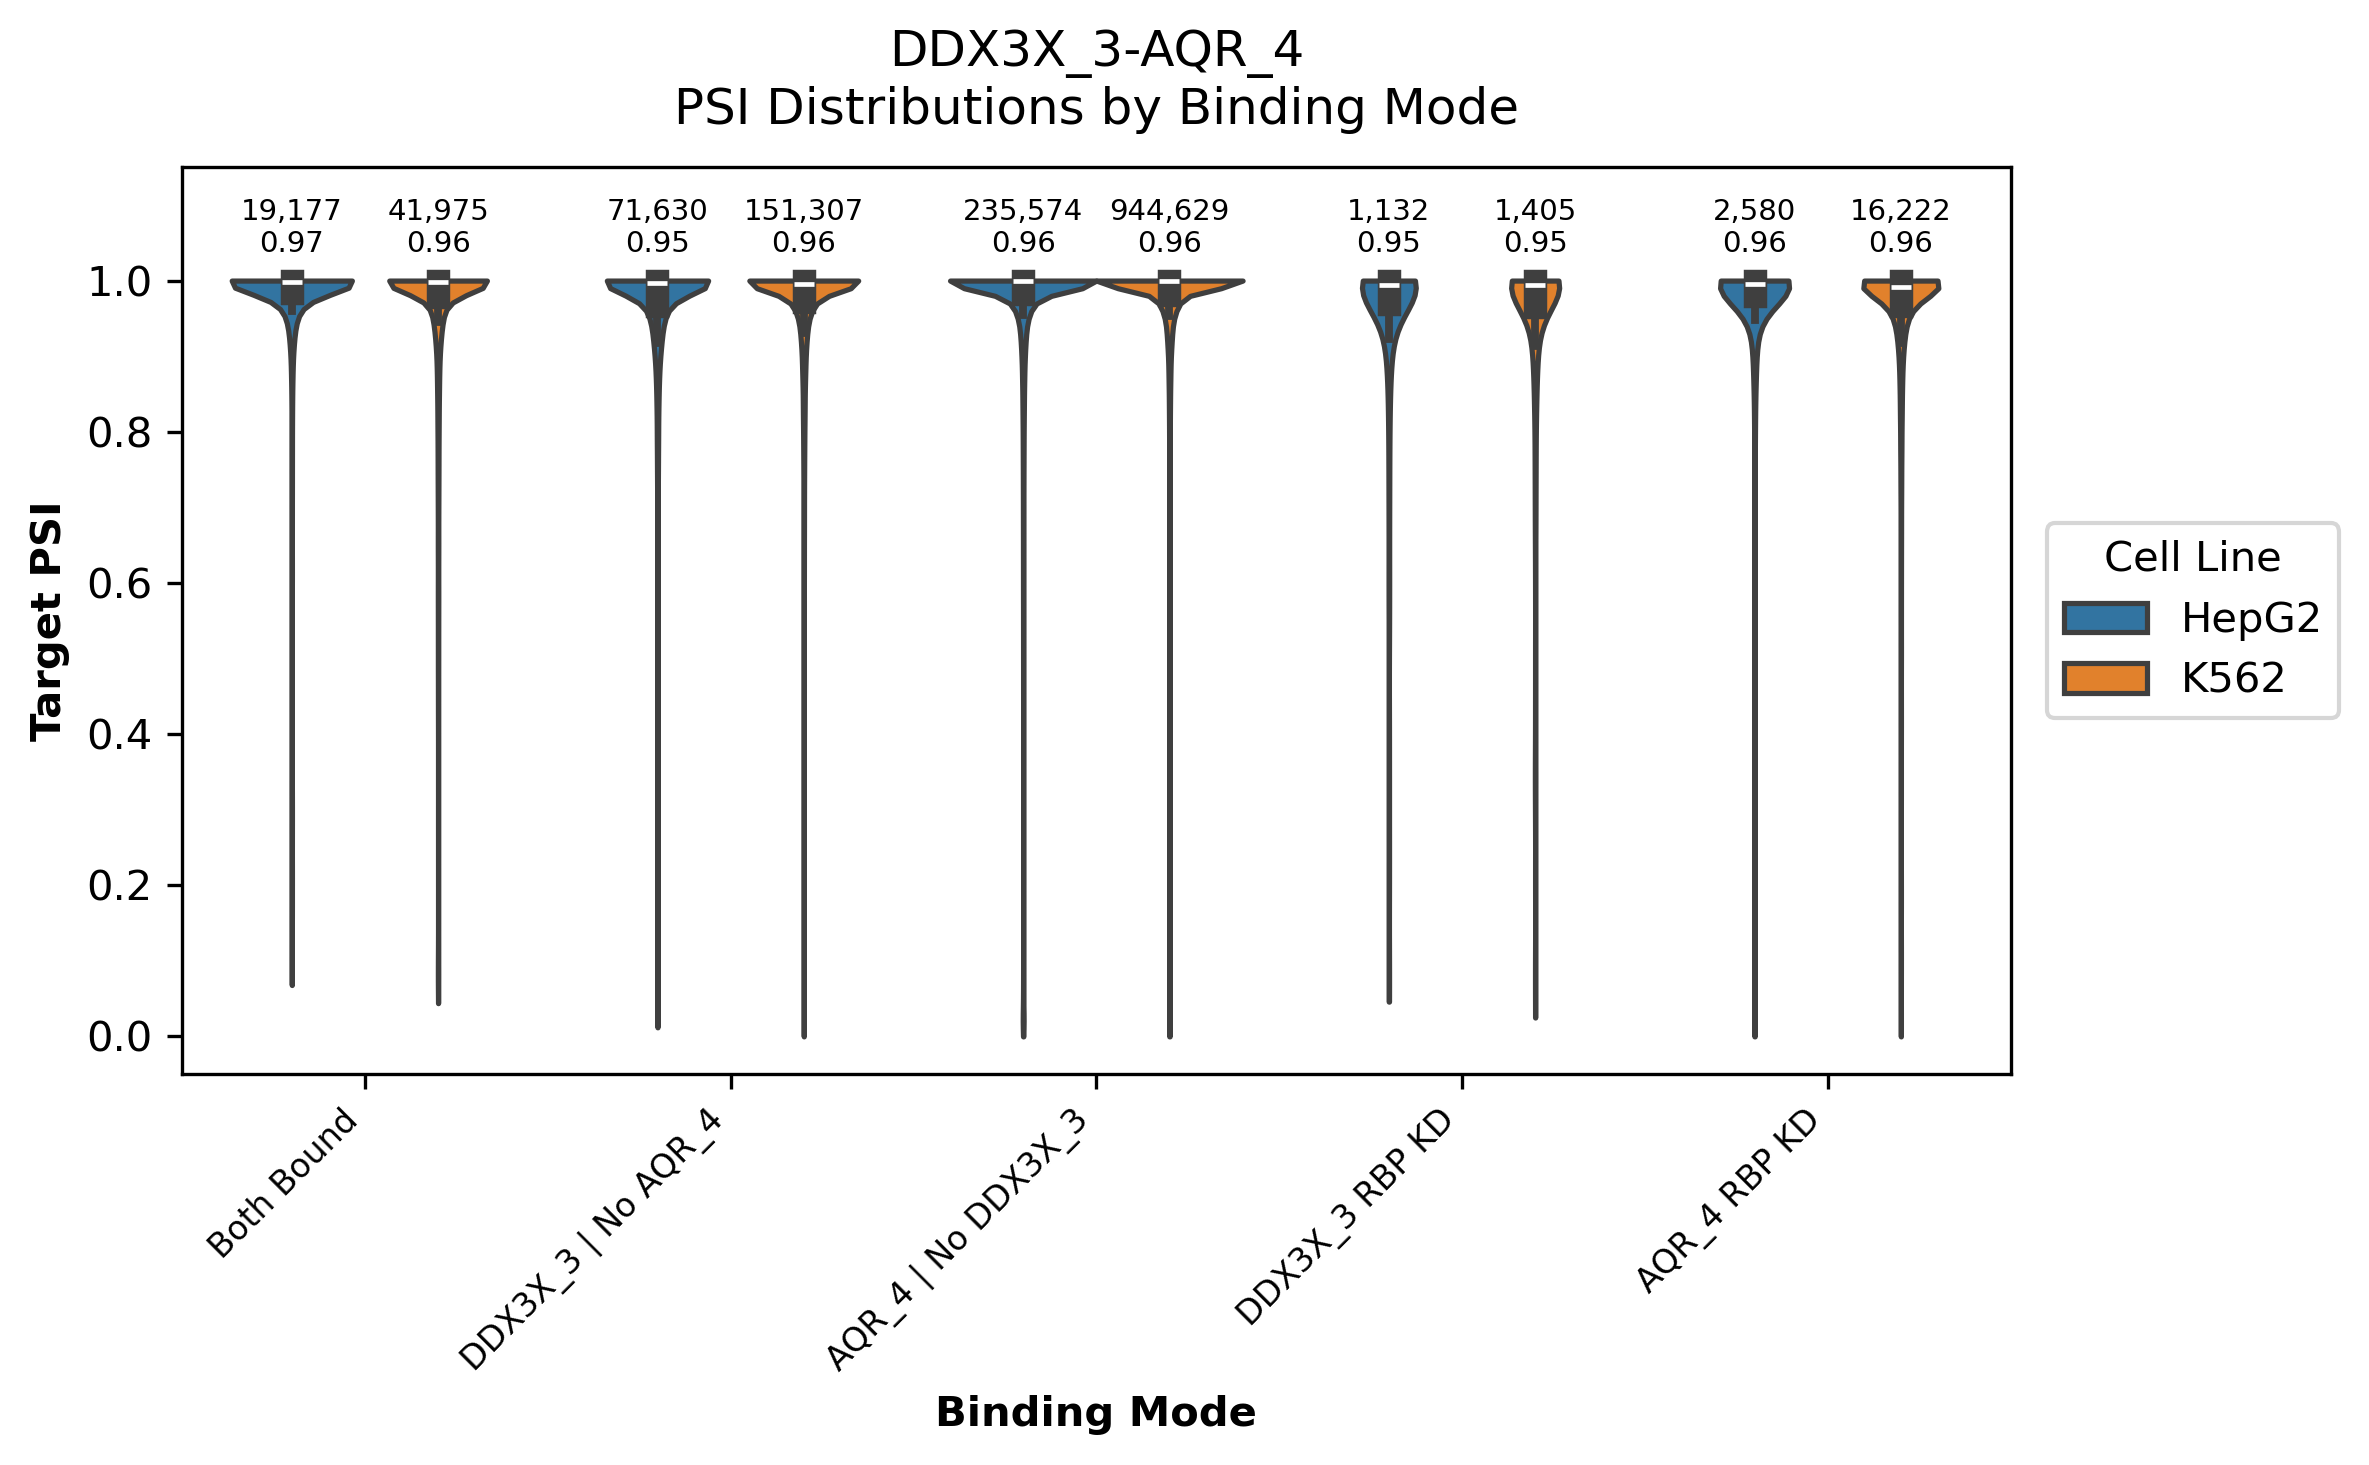

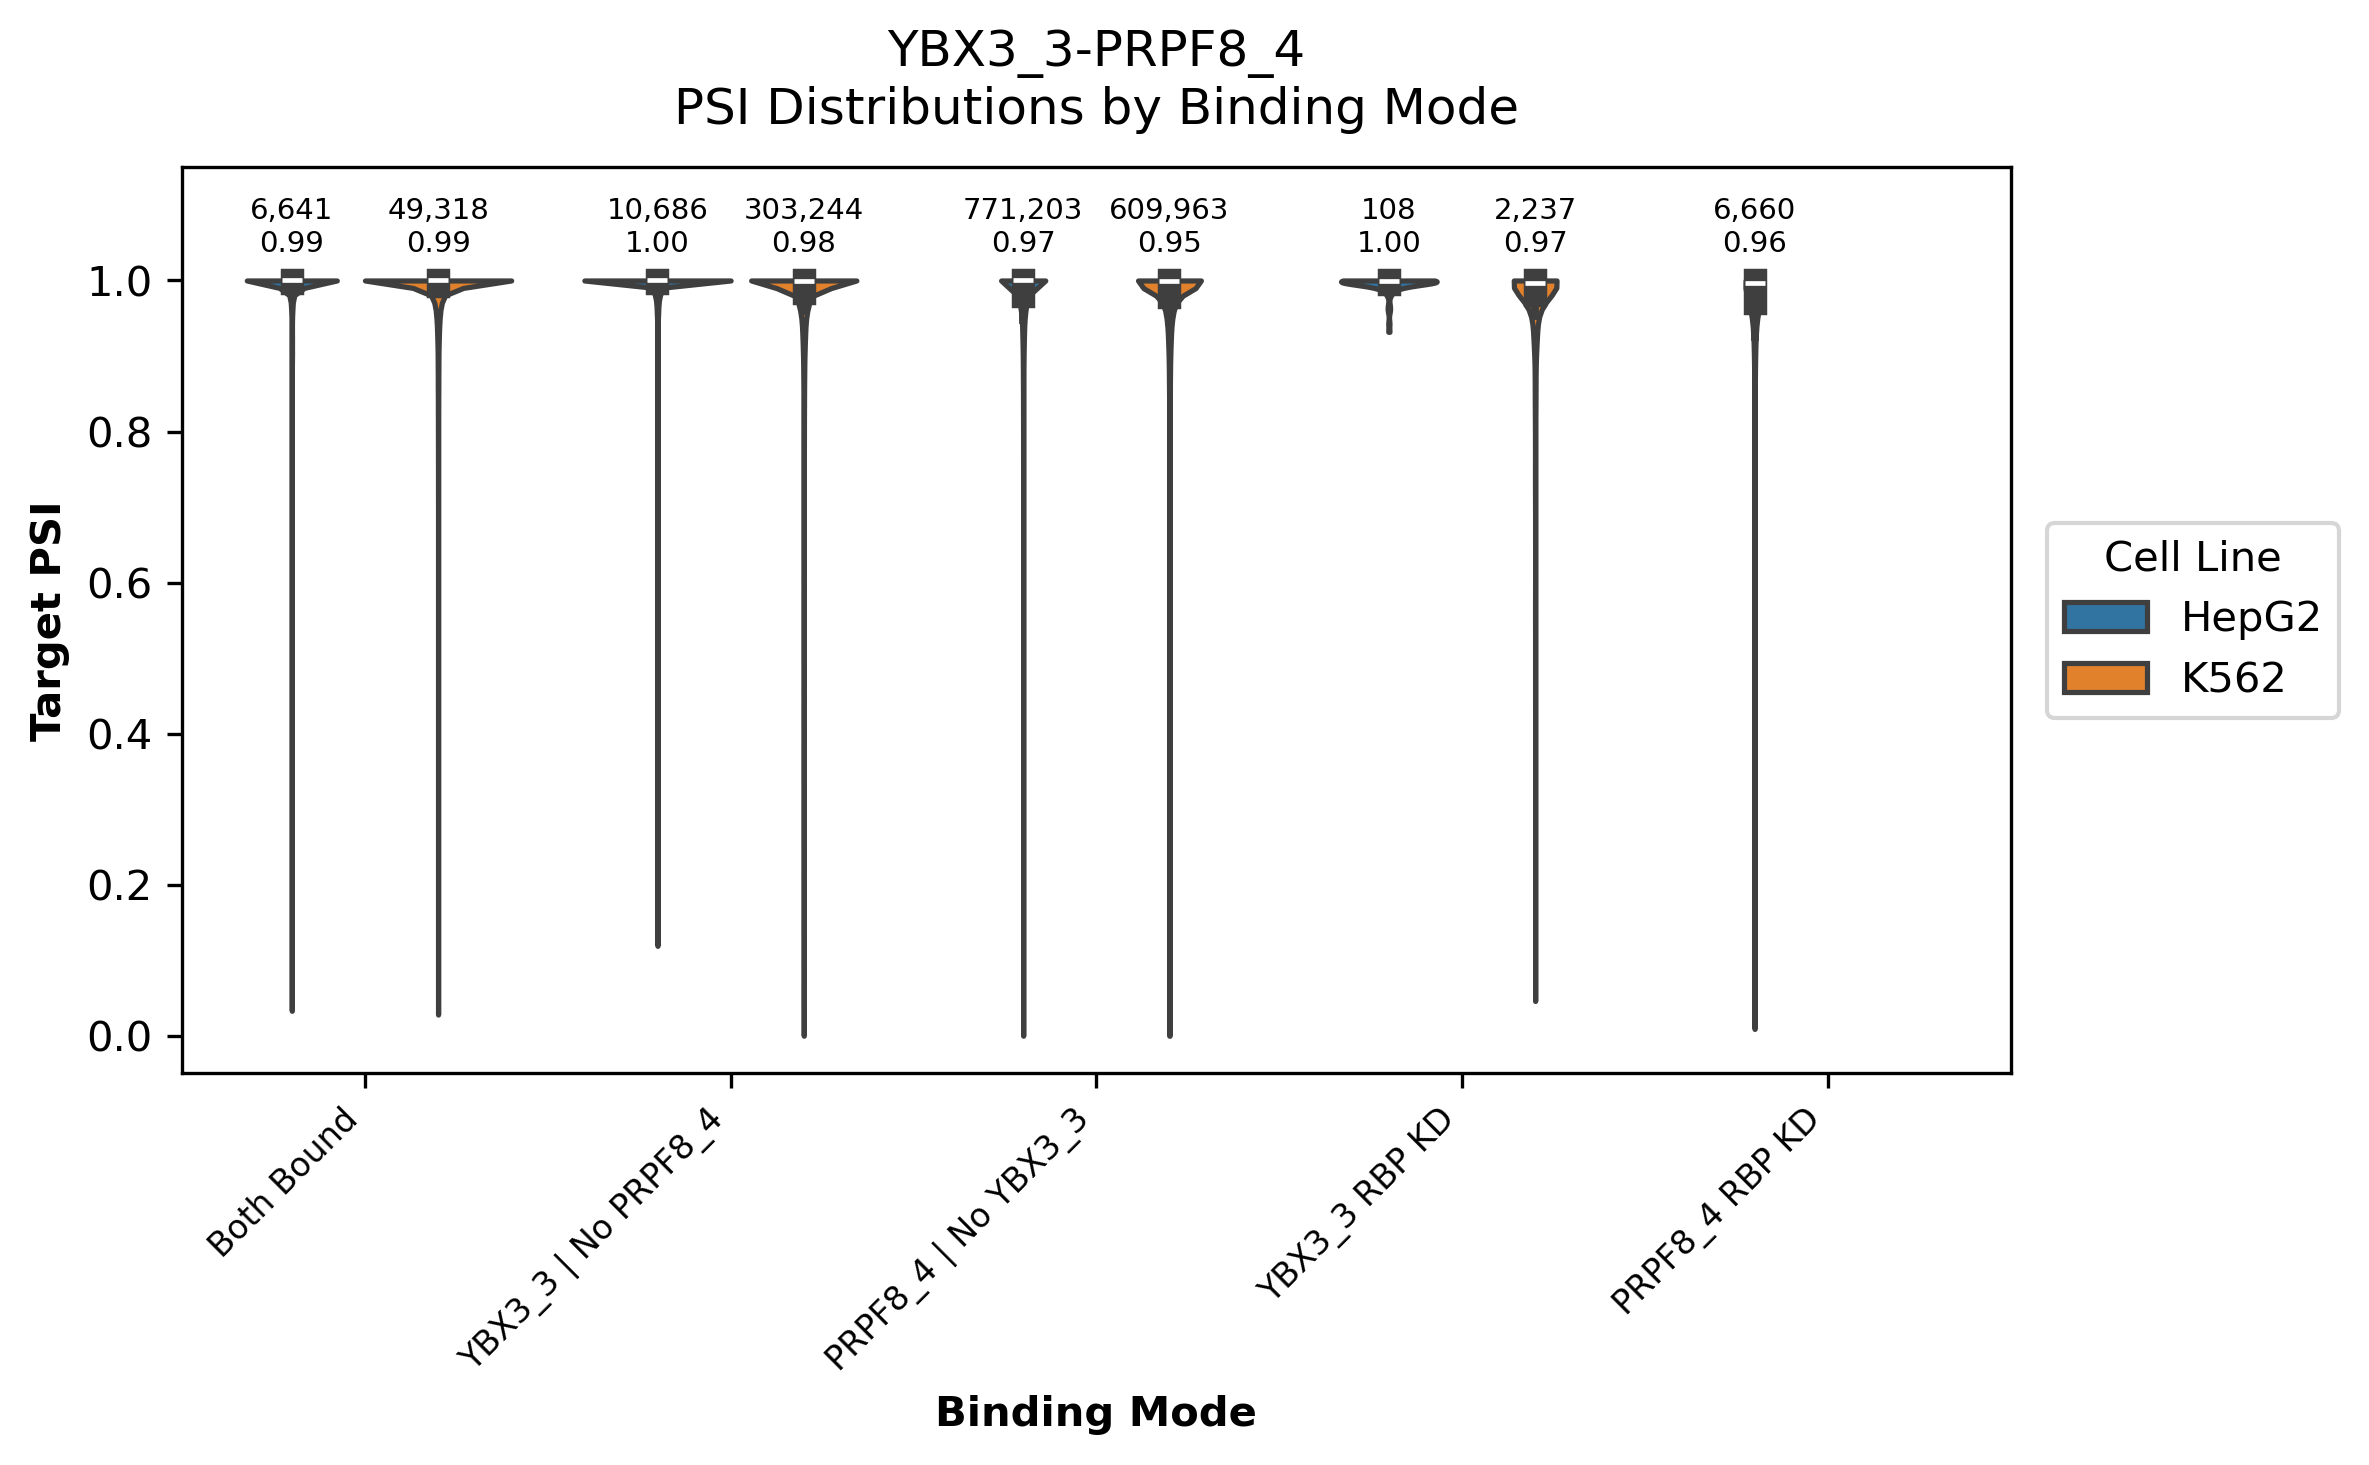

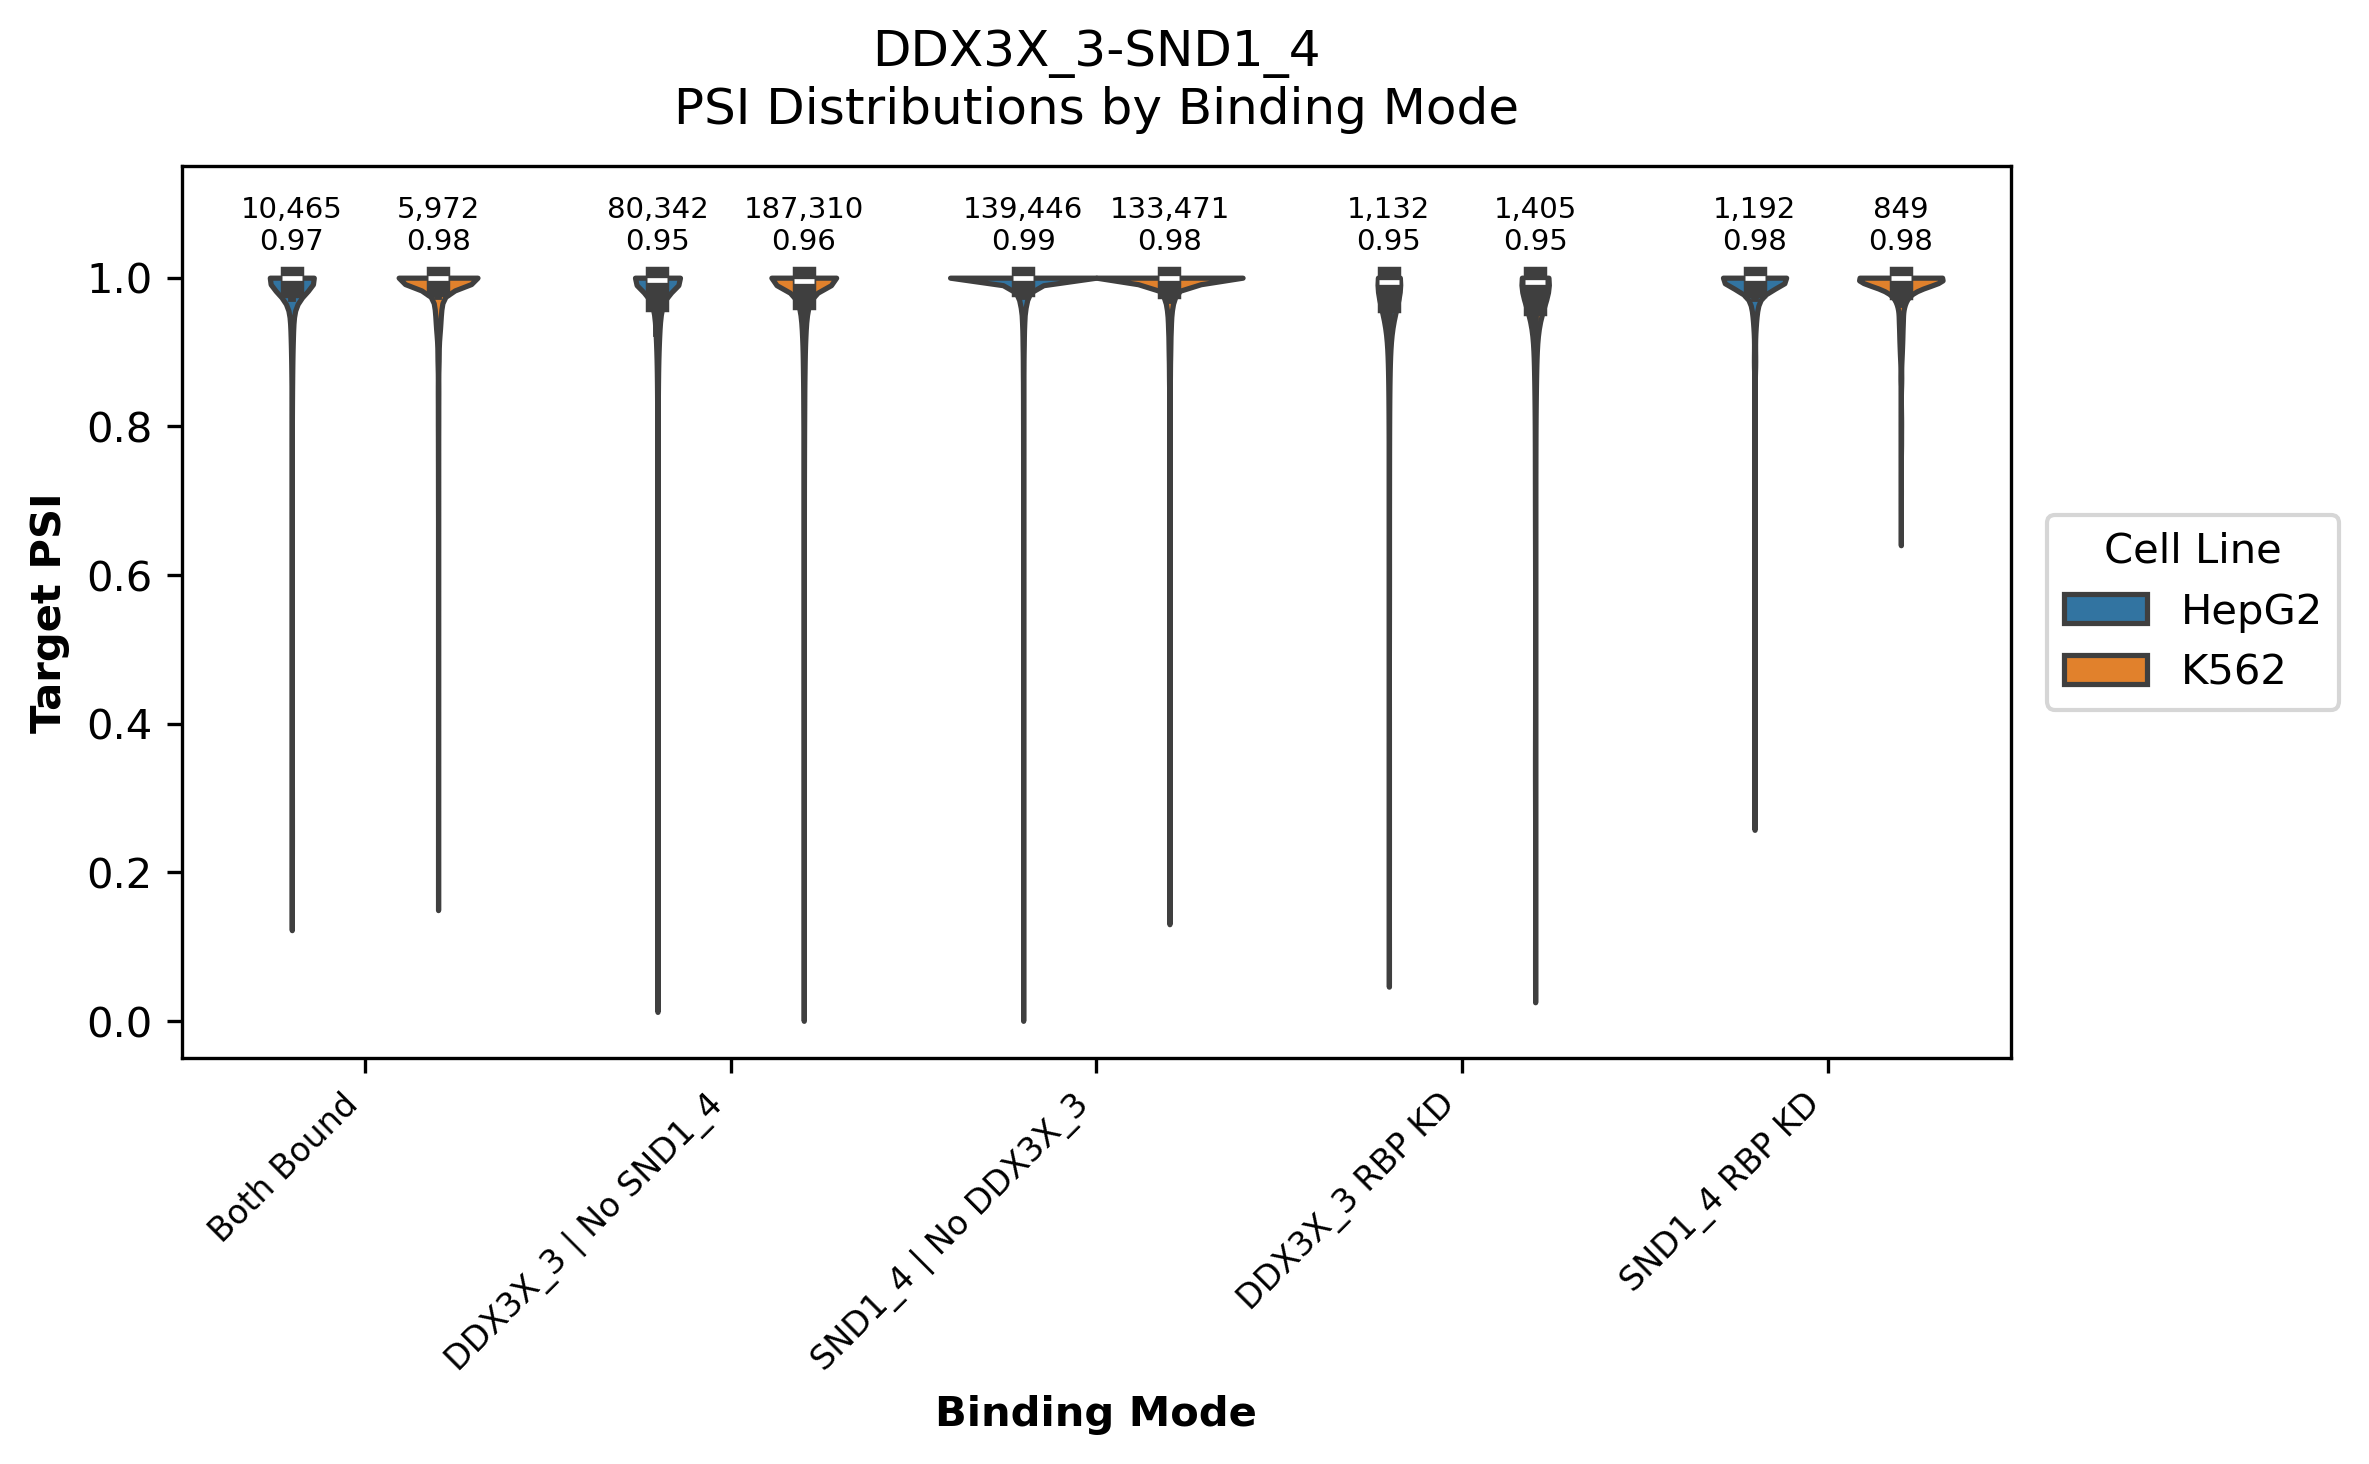

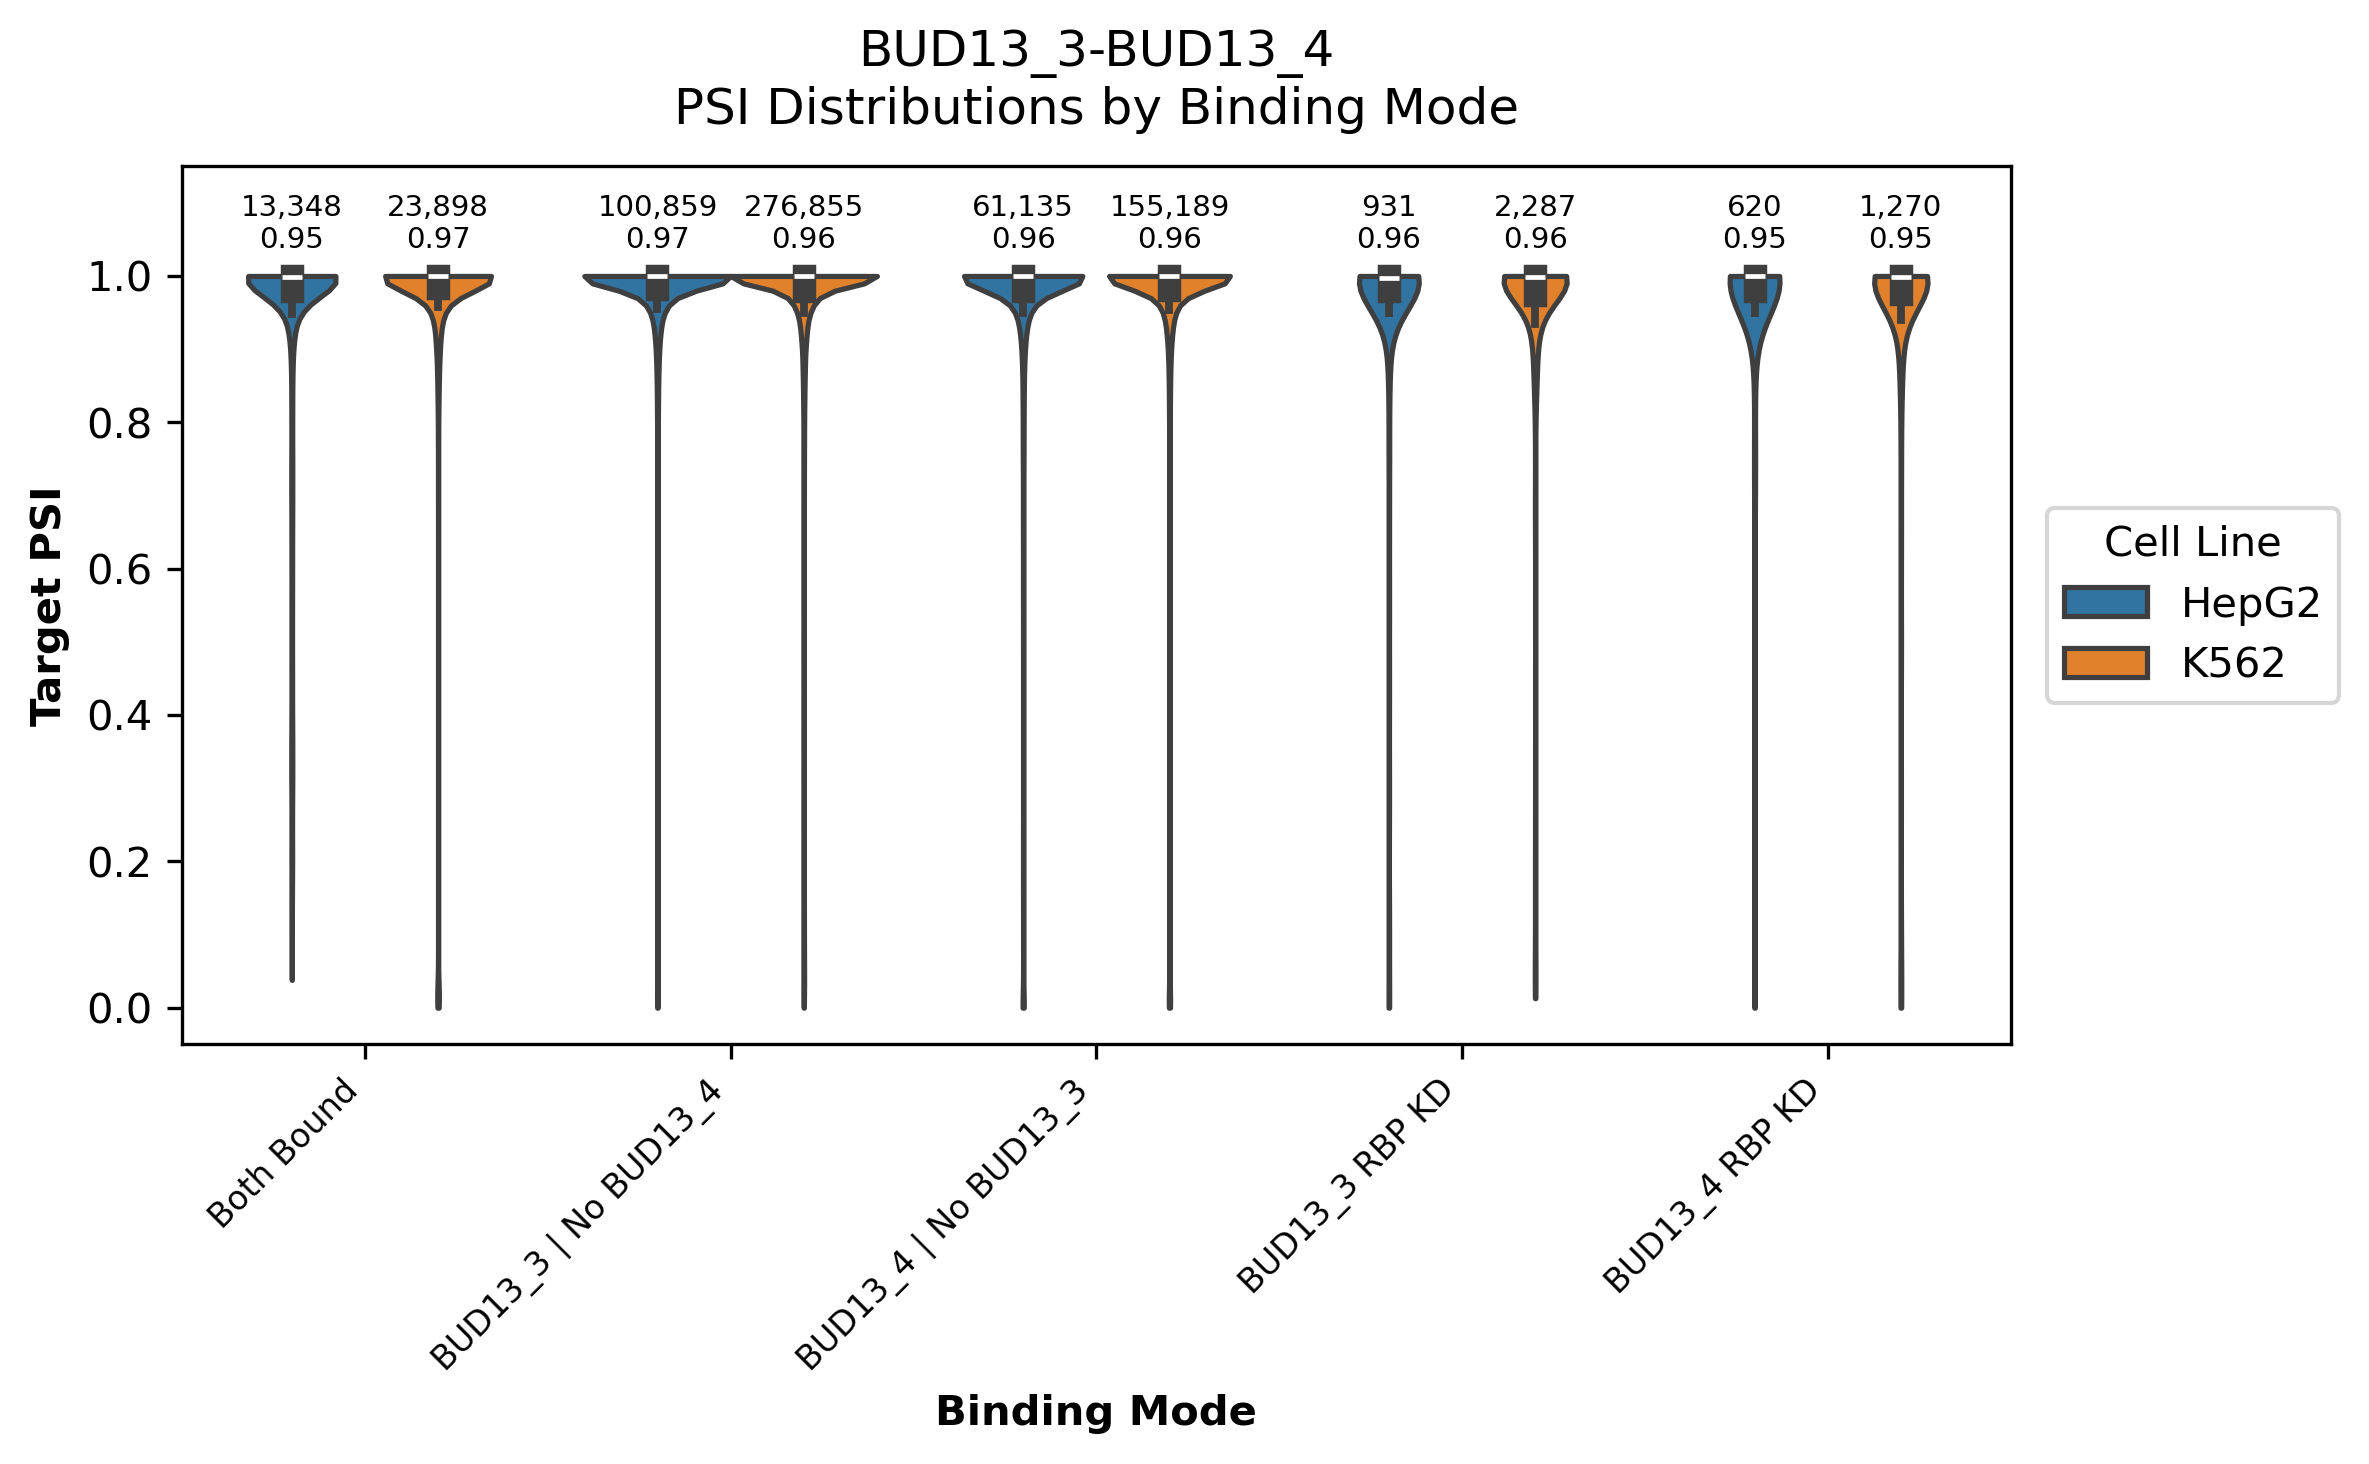

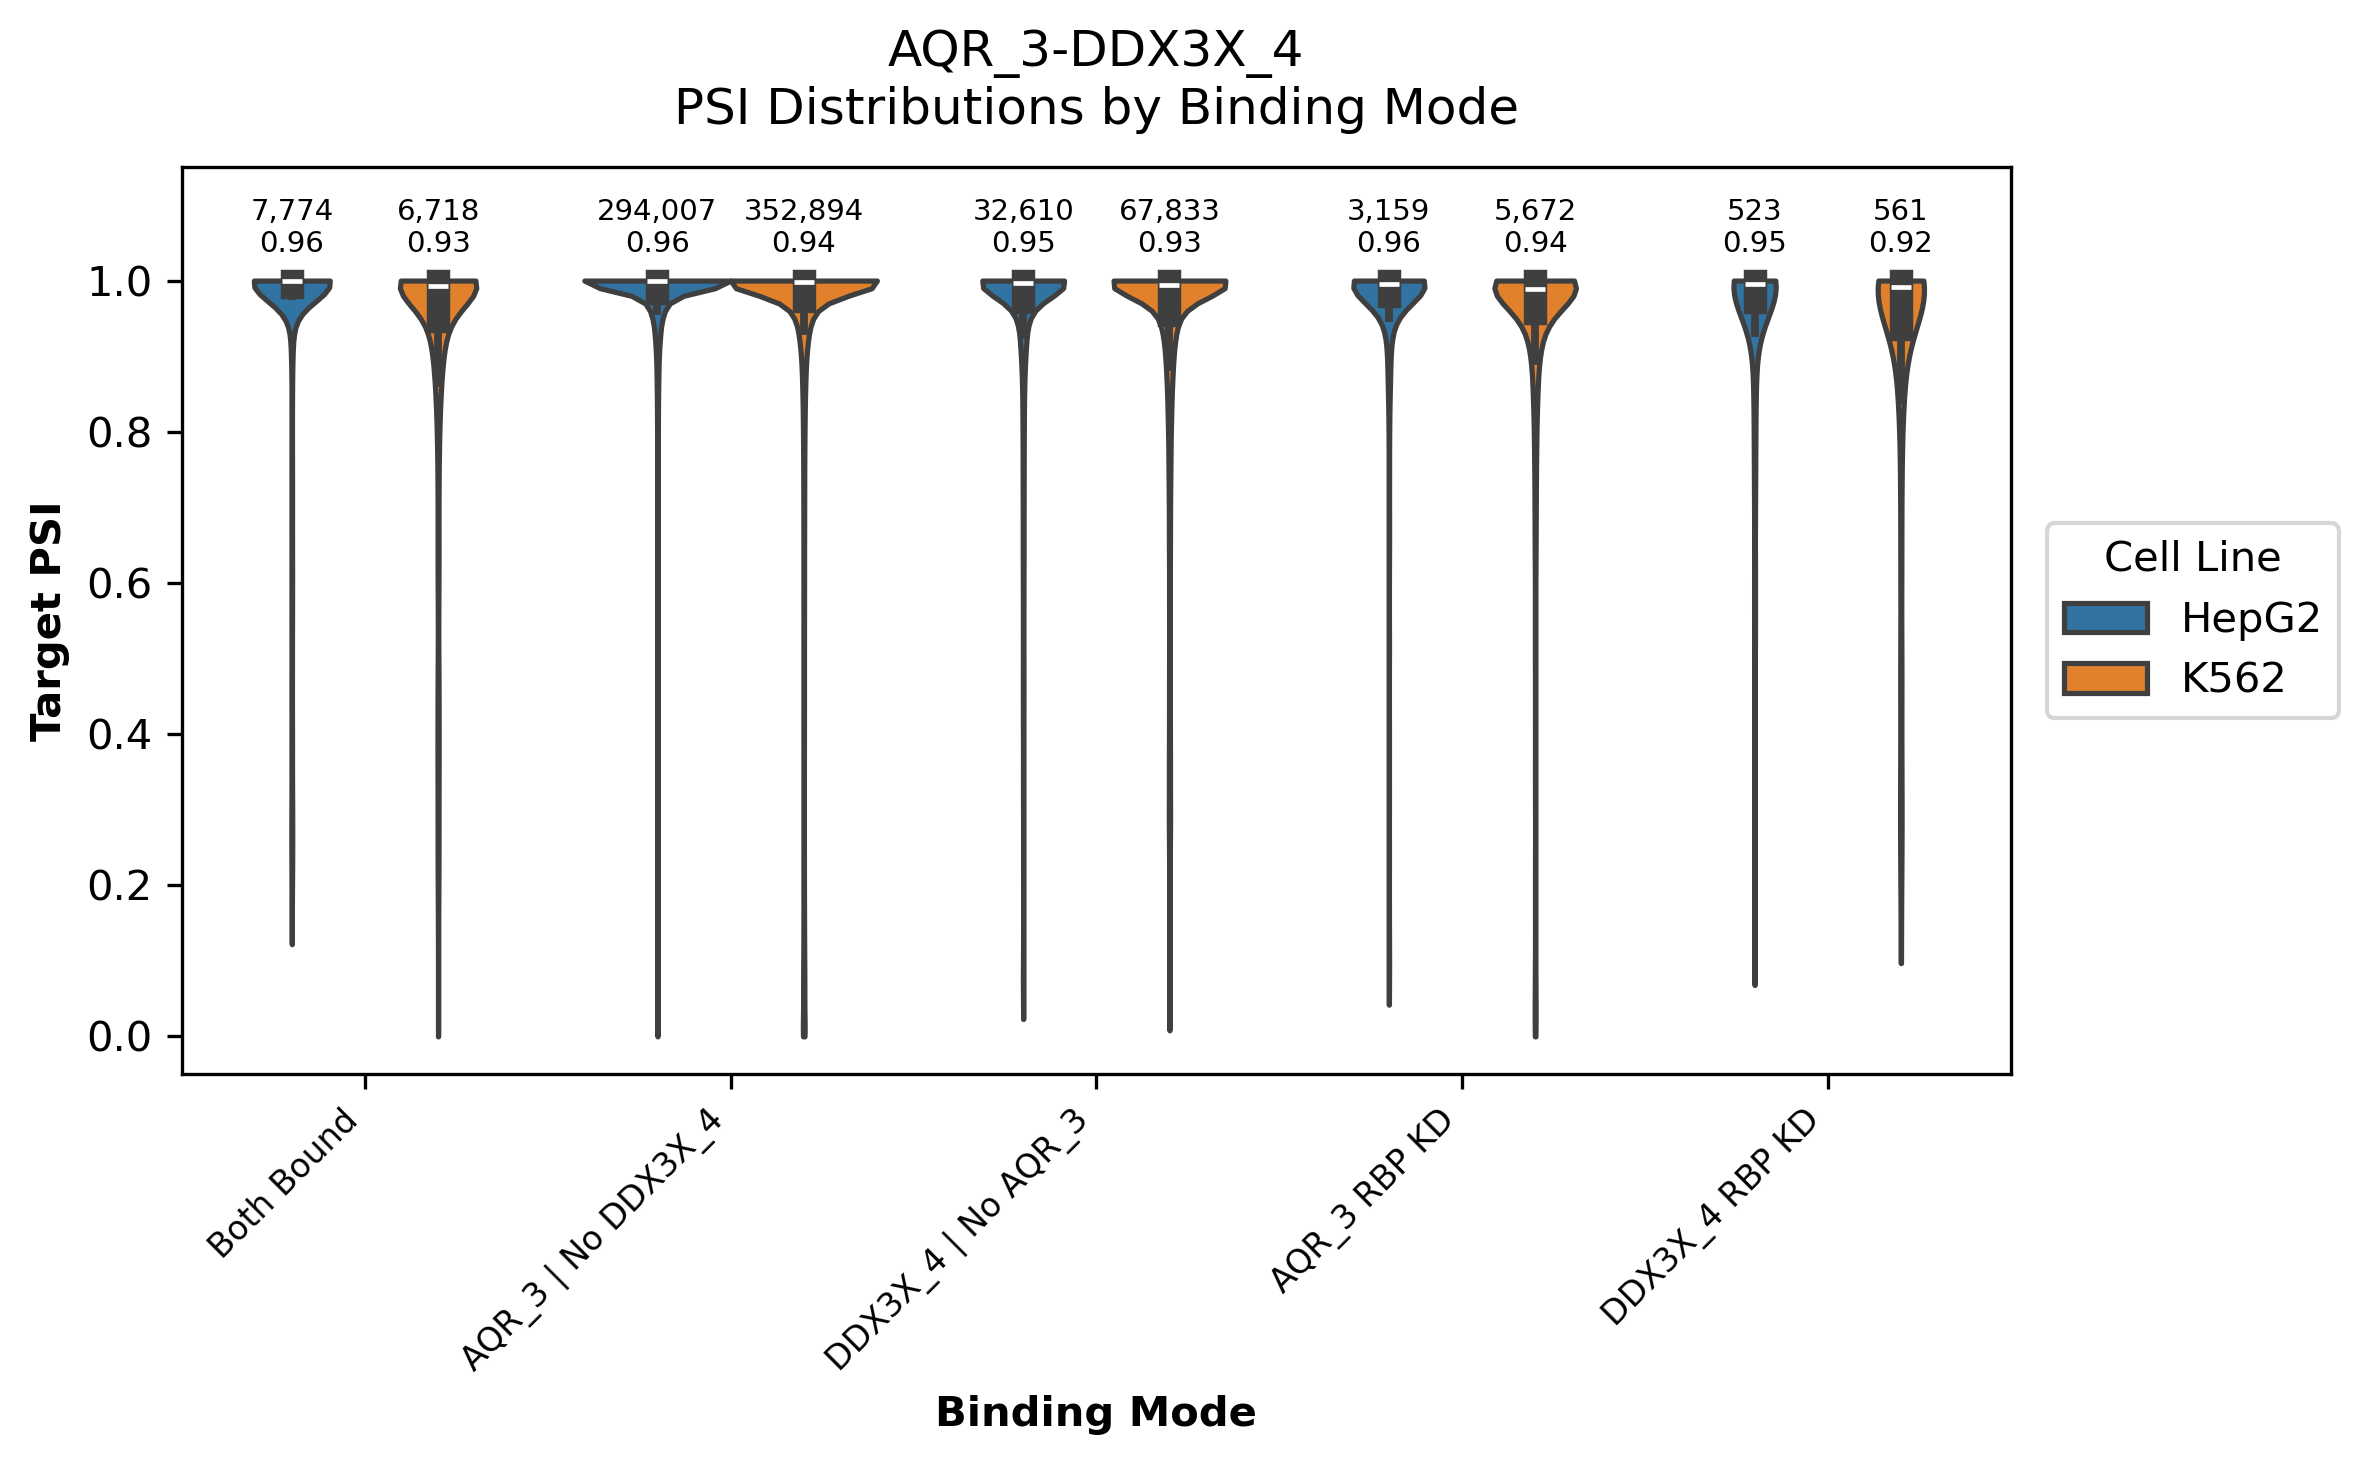

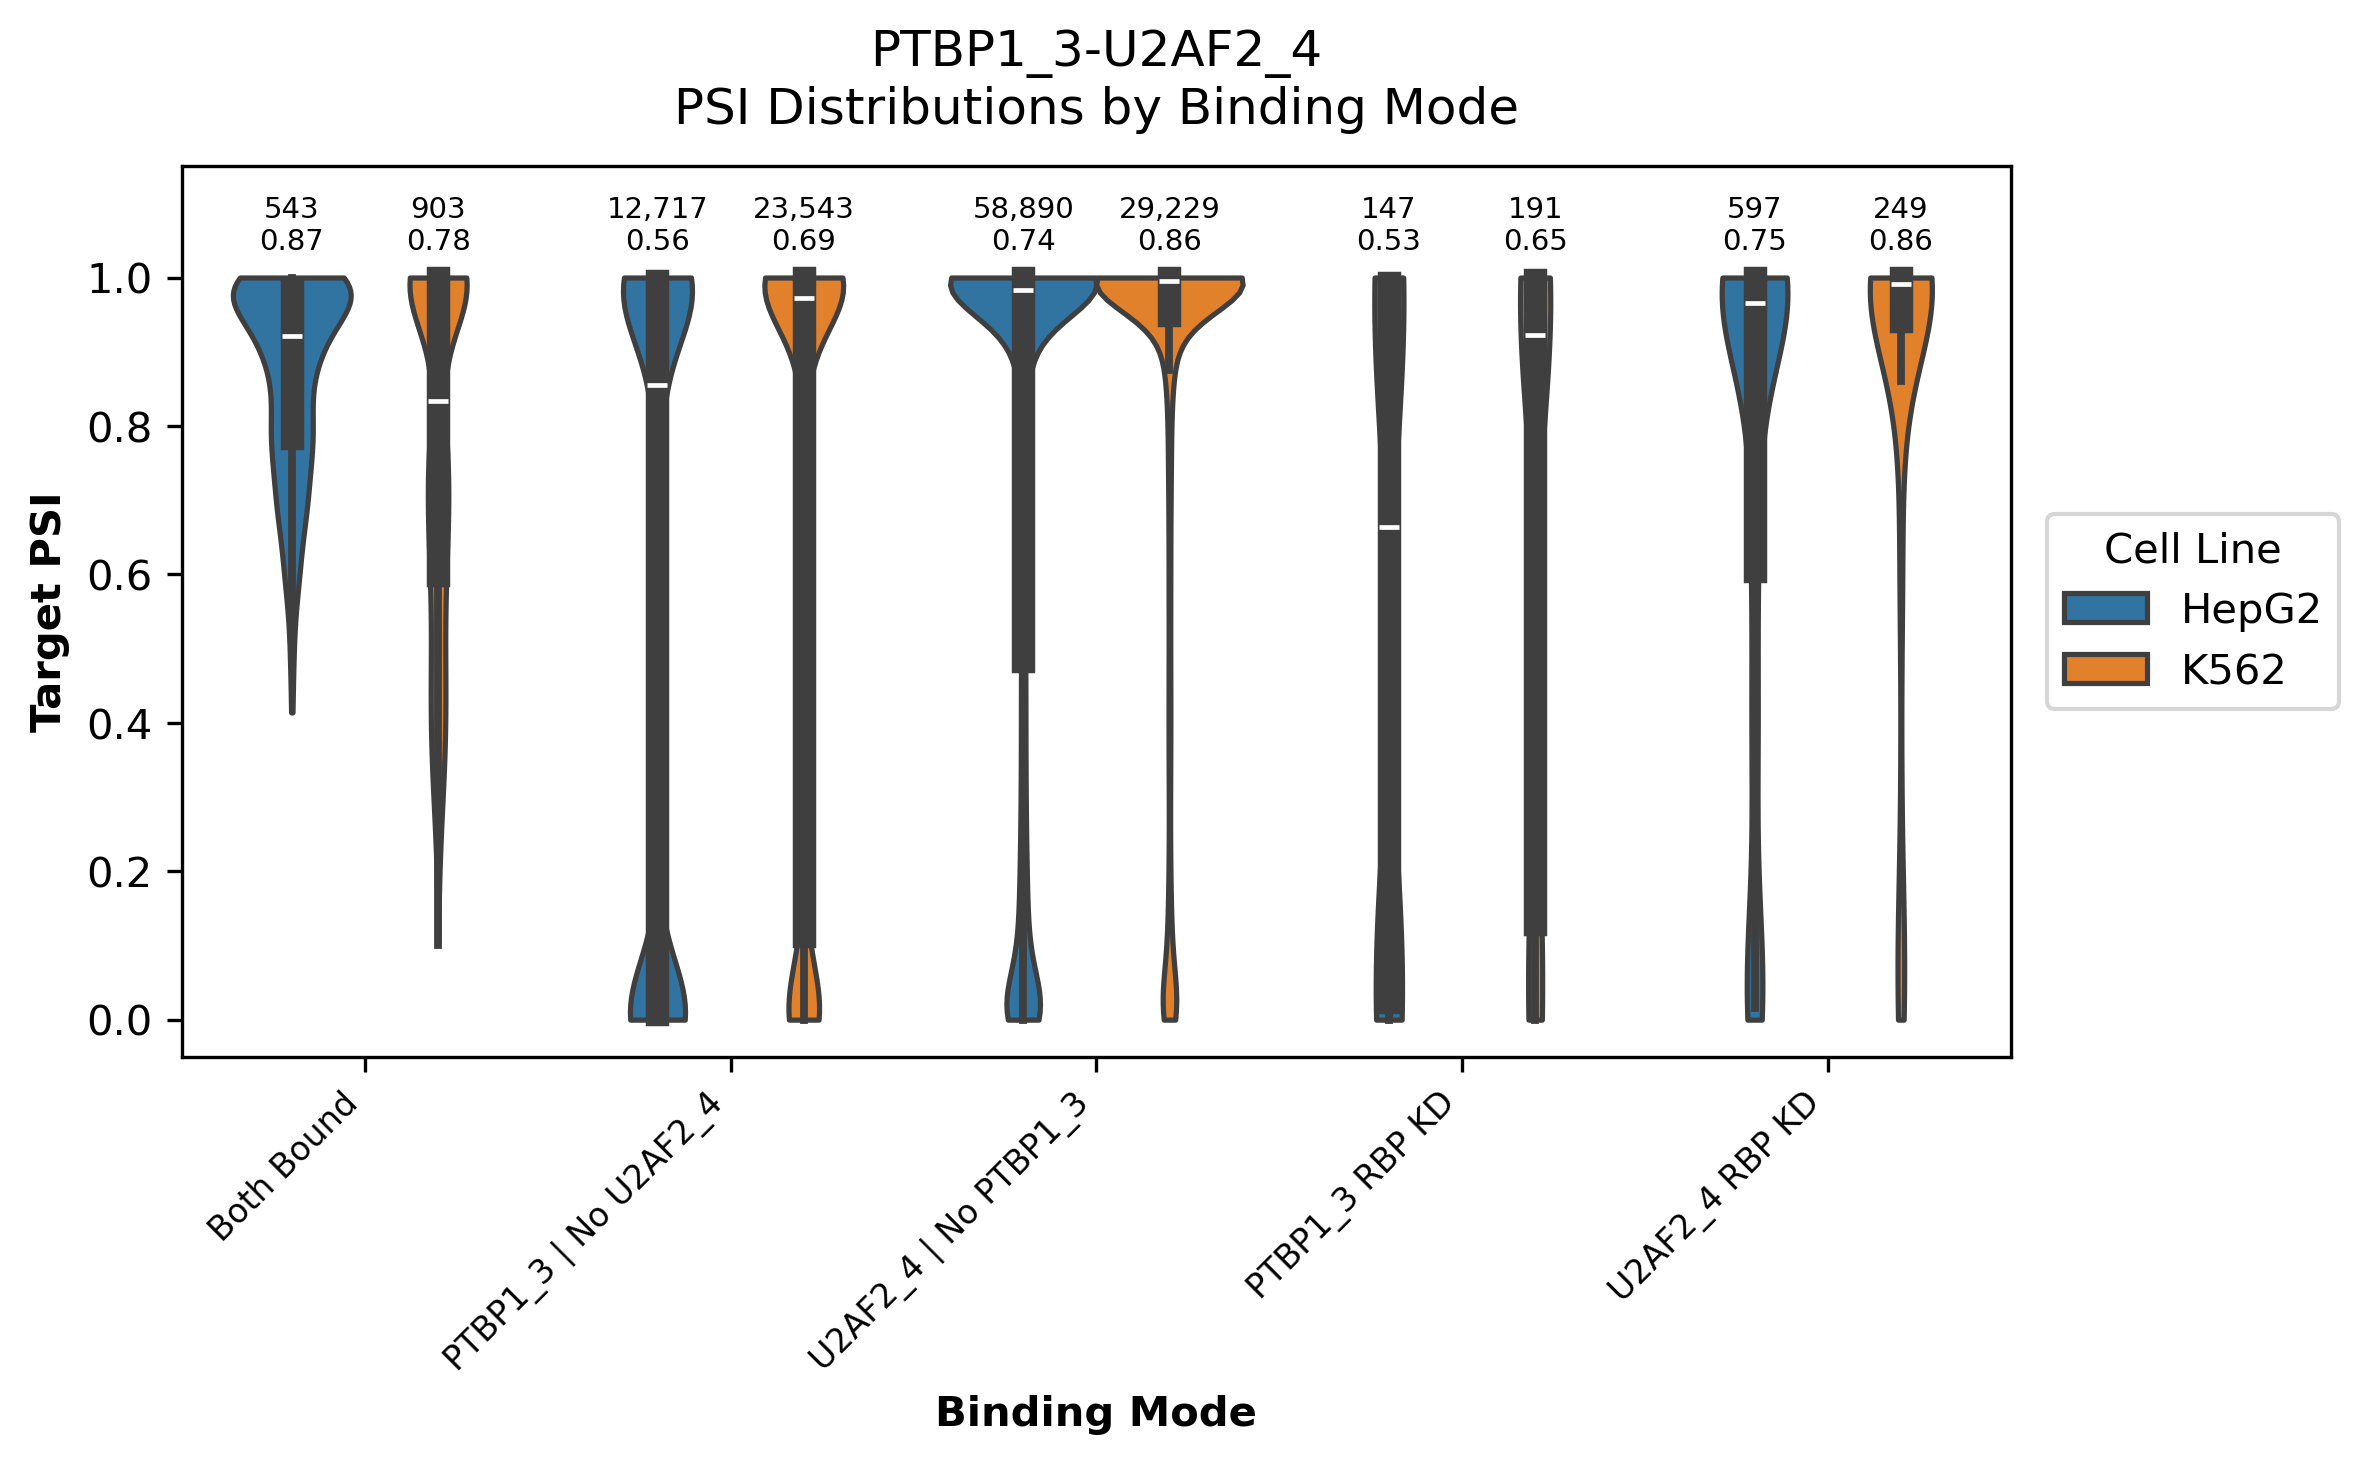

In [ ]:
analyzer.plot_psi_distributions_for_selected_features()

In [ ]:
analyzer.plot_interaction_opposite_effect_vs_main_effect()